# Regime Change Detection Feature Engineering

This notebook loads BTC Deribit market data, engineers the regime-change features used in the project, and visualizes a few simple volatility-based regime labels.


In [8]:
from regime_change_utils import (
    add_binary_high_vol_regime,
    engineer_regime_change_features,
    load_or_create_deribit_dataset,
    plot_binary_regime,
    plot_returns_vs_volatility,
    plot_volatility_regimes,
    save_enriched_dataset,
)


In [9]:
DATA_CSV_PATH = 'deribit_data.csv'
ENRICHED_CSV_PATH = 'deribit_enriched_data.csv'

raw_df = load_or_create_deribit_dataset(csv_path=DATA_CSV_PATH)
raw_df.head(3)


Fetching BTC_USDT OHLCV:   0%|          | 0/261 [00:00<?, ?it/s]

Fetching BTC-PERPETUAL Funding Rates: 100%|██████████| 61/61 [00:48<00:00,  1.25it/s]


Merged BTC data saved to 'deribit_data.csv'


,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,volume_perp,cost_perp,index_price,interest_8h,interest_1h,prev_index_price
timestamp,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,284.684758,11895930.0,41575.99,0.000083,9.306260e-07,41801.40
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,583.245790,24440950.0,41842.93,0.000066,7.146489e-06,41575.99
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,1110.233834,46157810.0,41798.09,0.000057,8.726458e-06,41842.93


In [10]:
df = engineer_regime_change_features(raw_df)
output_path = save_enriched_dataset(df, csv_path=ENRICHED_CSV_PATH)

print(f'Engineered dataset saved to {output_path}')
print(f'Total columns: {len(df.columns)}')
df.head(3)


Engineered dataset saved to deribit_enriched_data.csv
Total columns: 81


,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,...,std_72h_sq_return_close_perp,std_72h_sq_return_index_price,ATR_24h_spot,ATR_72h_spot,ATR_24h_spot_norm,ATR_72h_spot_norm,ATR_24h_perp,ATR_72h_perp,ATR_24h_perp_norm,ATR_72h_perp_norm
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The refactor keeps the engineered column names the downstream workflow already expects, but moves the long feature logic into regime_change_utils.py so the notebook stays focused on analysis.


(<Figure size 1400x600 with 2 Axes>,
 (<Axes: title={'center': 'Returns vs Rolling Volatility'}, xlabel='timestamp', ylabel='Returns'>,
  <Axes: xlabel='timestamp', ylabel='Volatility'>))

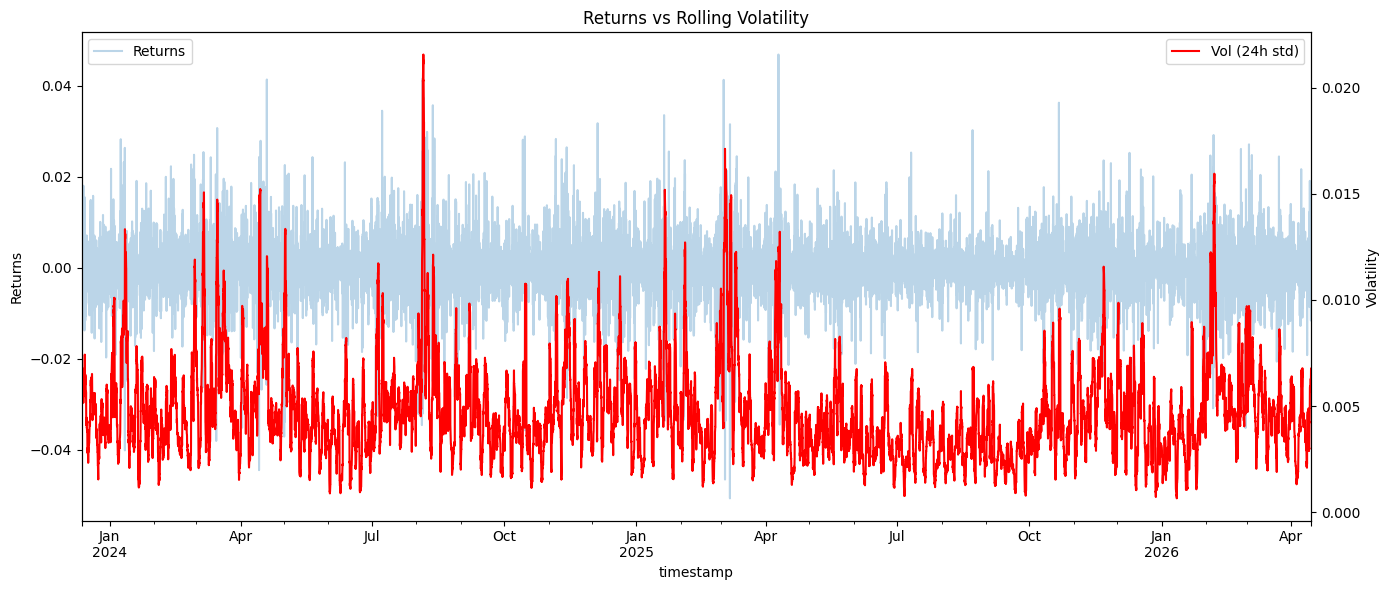

In [11]:
plot_returns_vs_volatility(df)


This chart compares BTC hourly returns with rolling 24-hour volatility. Large return shocks and rising volatility still cluster together, which is why rolling volatility is a reasonable first-pass rule-based regime signal.


High-volatility threshold (75th percentile): 0.005798


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'High Volatility Regimes'}, ylabel='Regime'>)

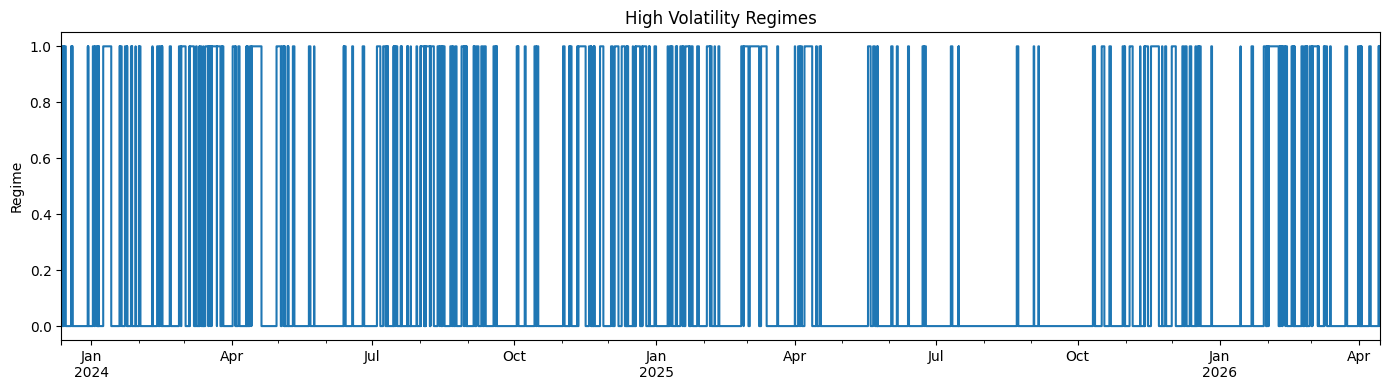

In [12]:
df, high_vol_threshold = add_binary_high_vol_regime(df)
print(f'High-volatility threshold (75th percentile): {high_vol_threshold:.6f}')
plot_binary_regime(df)


The binary high_vol label switches on when 24-hour volatility moves above its upper quartile. That keeps the regime logic simple and makes it easy to compare later against richer latent-state models.


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Volatility Regimes (Based on 72h Std)'}, ylabel='Volatility'>)

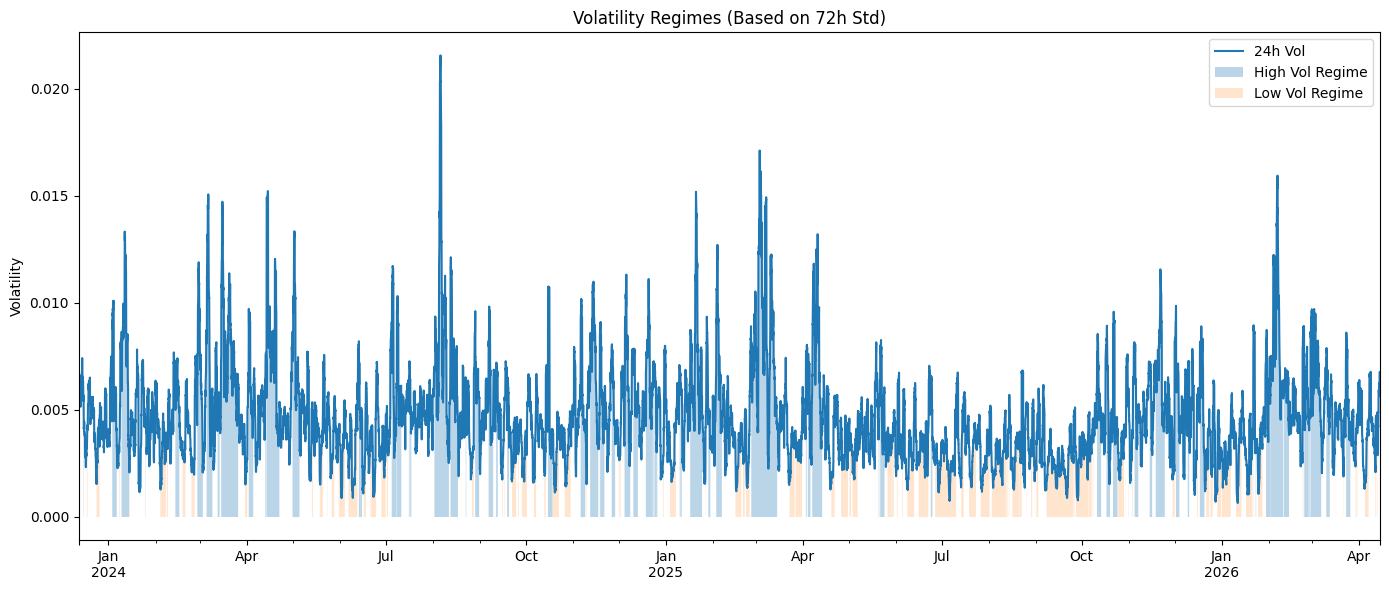

In [13]:
plot_volatility_regimes(df)


The shaded chart uses the slower 72-hour volatility signal to mark calm and stressed periods while plotting the faster 24-hour series. It gives a cleaner visual separation between persistent quiet regimes and more turbulent stretches.
